In [1]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torch.nn as nn
import pandas as pd
import numpy as np
from transformers import BertModel, AutoTokenizer
from datasets import load_dataset
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
import random
import torch.optim as optim
import os

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


In [3]:
def compute_metrics(y_true,y_pred):
    acc = accuracy_score(y_true,y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return f1, acc

# Custom Dataset and Dataloader

In [10]:
MODEL_NAME = "distilbert-base-multilingual-cased"
MAX_LENGTH = 256


In [4]:
class CustomDataset(Dataset):
    def __init__(self, tokenizer, max_length, subset_size=None):
        full_data = load_dataset("SetFit/amazon_reviews_multi_fr")["train"]

        if subset_size is not None and subset_size < len(full_data):
            # Convert to pandas for easier stratified sampling
            df = full_data.to_pandas()

            # Calculate samples per class to ensure even distribution
            n_classes = df['label'].nunique()
            samples_per_class = subset_size // n_classes

            # Stratified sampling
            df_subset = df.groupby('label').apply(lambda x: x.sample(samples_per_class, random_state=42)).reset_index(drop=True)
            self.data = df_subset
        else:
            self.data = full_data

        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data.iloc[idx] if isinstance(self.data, pd.DataFrame) else self.data[idx]

        review = item["text"]
        original_label = item["label"]

        # Mapping
        if original_label in [0, 1]:
            mapped_label = 0
        elif original_label == 2:
            mapped_label = 1
        else:
            mapped_label = 2

        encoding = self.tokenizer(
            review,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(mapped_label, dtype=torch.long)
        }

In [8]:
def create_dataloaders(
    dataset,
    batch_size=16,
    train_ratio=0.8,
    seed=42,
    sampler=None):
    train_size = int(train_ratio*len(dataset))
    val_size = len(dataset) - train_size

    generator = torch.Generator().manual_seed(seed)

    train_dataset, val_dataset = random_split(dataset,
        [train_size, val_size],
        generator = generator)

    train_sampler = None
    if sampler is not None:
        train_weigths = sampler[train_dataset.indices]
        train_sampler = WeightedRandomSampler(
            train_weigths, len(train_dataset))
    train_loader  = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle= (train_sampler is None),
        sampler = train_sampler
    )


    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )
    return train_loader, val_loader

In [ ]:
data_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
allocine_dataset = CustomDataset(data_tokenizer, max_length=MAX_LENGTH, subset_size=20000)
print(f"Dataset size: {len(allocine_dataset)}")

Dataset size: 20000


/tmp/ipykernel_17556/846063030.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_subset = df.groupby('label').apply(lambda x: x.sample(samples_per_class, random_state=42)).reset_index(drop=True)


In [12]:
train_loader, val_loader = create_dataloaders(allocine_dataset)

In [13]:
total_batches =len(train_loader)
print(f"One epoch will take {total_batches} steps.")

One epoch will take 1000 steps.


In [14]:
total_samples = len(train_loader.dataset)
print(f"Total number of samples: {total_samples}")

Total number of samples: 16000


# Model creation

In [16]:
from transformers import AutoModel

class BertClassifier(nn.Module):
    def __init__(self, model_name, n_classes):
        super().__init__()
        self.pretrained = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Linear(self.pretrained.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.pretrained(input_ids=input_ids, attention_mask=attention_mask)
        # Pour DistilBERT, on utilise la sortie du token [CLS] (index 0)
        # accessible via outputs.last_hidden_state[:, 0, :]
        pooled_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(pooled_output)
        return logits

In [17]:
def train_epochs(model, optimizer, criterion, train_loader, device="cpu"):
  train_loss = 0
  all_preds = []
  all_labels = []
  total_sample = 0
  model.train()

  progress_bar = tqdm(train_loader, desc="Training",leave=False)
  for batch in progress_bar:
    optimizer.zero_grad()
    labels = batch["labels"].to(device)
    inputs = batch['input_ids'].to(device)
    attention_mask = batch["attention_mask"].to(device)
    output = model(inputs, attention_mask)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    b = labels.size(0)
    preds = output.argmax(dim=1)
    total_sample += b
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(preds.cpu().numpy())
    progress_bar.set_postfix(loss=f"{train_loss/total_sample:.4f}")

  if total_sample == 0:
    return 0.0, 0.0, 0.0
  avg_loss = train_loss/total_sample
  train_acc,_ = compute_metrics(all_labels, all_preds)
  return avg_loss, train_acc



In [18]:
def eval_epoch(model, criterion, eval_loader, device="cpu"):
    val_loss = 0.0
    correct = 0.0
    total_sample = 0.0
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        progress_bar = tqdm(eval_loader, desc="Validation", unit="batch")
        for batch in progress_bar:
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            output = model(inputs, attention_mask=attention_mask)
            loss = criterion(output, labels)
            b = labels.size(0)
            val_loss += loss.item() * b
            preds = output.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            total_sample += b
            progress_bar.set_postfix(loss=f"{val_loss/total_sample:.4f}")
        if total_sample == 0:
            return 0.0, 0.0, 0.0
        avg_loss = val_loss / total_sample
        acc, f1 = compute_metrics(all_preds, all_labels)
        return avg_loss, acc, f1


In [19]:
MODEL_NAME = "distilbert-base-multilingual-cased"
BATCH_SIZE = 32
MAX_LENGTH = 256
EPOCHS = 10
LR = 2e-5
WEIGHT_DECAY = 0.01
PATIENCE = 3

In [ ]:
model = BertClassifier(MODEL_NAME, n_classes=3)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:
def save_best_model(model, current_val_loss, best_val_loss, model_name):
    if current_val_loss < best_val_loss:
        print(f"Validation loss improved from {best_val_loss:.4f} to {current_val_loss:.4f}. Saving model...")
        os.makedirs('models', exist_ok=True)
        torch.save(model.state_dict(), f'models/{model_name}_best_model.pt')
        return current_val_loss
    return best_val_loss

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Using device: cuda


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [ ]:
history = {
      "train_loss": [],
      "val_loss": [],
      "train_acc": [],
      "val_acc": [],
      "val_f1_score": []
  }

model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_loss = float('inf')
epochs_no_improve = 0

print(f"Début de l'entraînement sur {device}...")

for epoch in range(1, EPOCHS+1):
    train_loss, train_accuracy = train_epochs(
        model,
        optimizer,
        criterion,
        train_loader,
        device=device
    )
    val_loss, val_accuracy, val_f1 = eval_epoch(
        model,
        criterion,
        val_loader,
        device=device
    )

    # Early Stopping et sauvegarde
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_best_model(model, val_loss, float('inf'), "distilbert_fr")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s).")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_f1_score"].append(val_f1)
    history["val_acc"].append(val_accuracy)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_accuracy:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_accuracy:.4f}"
    )

    if epochs_no_improve >= PATIENCE:
        print("Early stopping triggered!")
        break

Début de l'entraînement sur cuda...


Validation: 100%|██████████| 250/250 [00:31<00:00,  7.85batch/s, loss=0.6435]


Validation loss improved from inf to 0.6435. Saving model...
Epoch 1/10 | train_loss=0.0447 train_acc=1.0000 | val_loss=0.6435 val_acc=0.7538


Validation: 100%|██████████| 250/250 [00:31<00:00,  7.83batch/s, loss=0.6125]


Validation loss improved from inf to 0.6125. Saving model...
Epoch 2/10 | train_loss=0.0349 train_acc=1.0000 | val_loss=0.6125 val_acc=0.7583


...

No improvement for 1 epoch(s).
Epoch 3/10 | train_loss=0.0284 train_acc=1.0000 | val_loss=0.6964 val_acc=0.7491


Validation: 100%|██████████| 250/250 [00:32<00:00,  7.79batch/s, loss=0.7578]


No improvement for 2 epoch(s).
Epoch 4/10 | train_loss=0.0214 train_acc=1.0000 | val_loss=0.7578 val_acc=0.7173


Validation: 100%|██████████| 250/250 [00:32<00:00,  7.80batch/s, loss=0.9247]

No improvement for 3 epoch(s).
Epoch 5/10 | train_loss=0.0148 train_acc=1.0000 | val_loss=0.9247 val_acc=0.7111
Early stopping triggered!


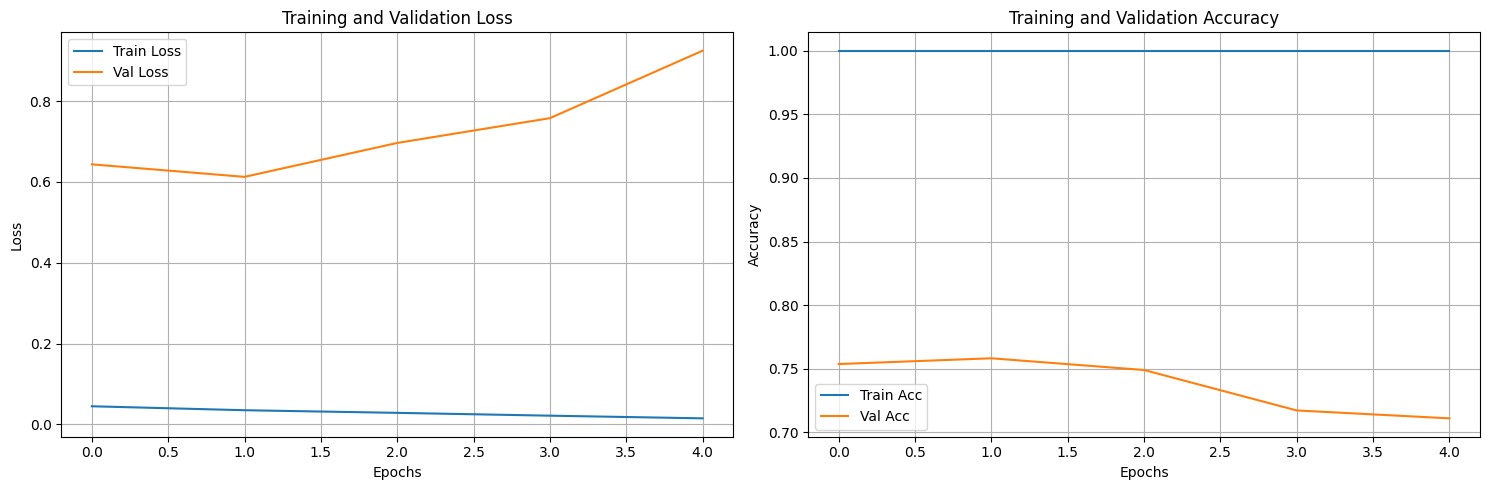

In [25]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'], label='Val Acc')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [26]:
checkpoint = {
    "model": model.state_dict(),
}

torch.save(checkpoint, "mon_checkpoint.pth")

In [27]:
path = "/content/mon_checkpoint.pth"
loaded_model = torch.load("/content/mon_checkpoint.pth")

In [28]:
loaded_model['model']['classifier.weight']

tensor([[-0.0132,  0.0258, -0.0380,  ..., -0.0318, -0.0293,  0.0316],
        [-0.0328,  0.0057, -0.0174,  ...,  0.0162, -0.0184,  0.0170],
        [ 0.0026, -0.0024, -0.0060,  ..., -0.0255, -0.0105, -0.0262]],
       device='cuda:0')

In [29]:
test_sample = "Des aides du #gouvernement pour des #logements plus #écologiques. "

In [ ]:
import torch.nn.functional as F

def predict(text, model, tokenizer, device, max_length=256):
    model.eval()
    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        try:
            logits = model(input_ids, attention_mask)
            probs = F.softmax(logits, dim=1)
            confidence, prediction = torch.max(probs, dim=1)
            return prediction.item(), confidence.item()
        except Exception as e:
            return None, str(e)

# Mapping complet pour 3 classes
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

# Inférence
prediction, confidence = predict(test_sample, model, tokenizer, device)

if prediction is not None:
    print(f"Text: {test_sample}")
    print(f"Predicted Class: {prediction} ({label_map.get(prediction, 'Unknown')})")
    print(f"Confidence Score: {confidence:.4f}")
else:
    print(f"Erreur lors de la prédiction : {confidence}")
    print("Note : Si l'erreur CUDA persiste, redémarrez le runtime (Menu Exécution > Redémarrer le runtime).")

Text: Des aides du #gouvernement pour des #logements plus #écologiques. 
Predicted Class: 2 (Positive)
Confidence Score: 0.9537


In [85]:
!pip install huggingface_hub